# Pertemuan 9 — Algoritma Klasifikasi: Prediksi Diagnosis

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [1]:
# Langkah 1: Load & EDA Singkat
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0=Malignant, 1=Benign

print('Shape:', X.shape)
print('\nDistribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))
print('\n0 = Malignant (ganas), 1 = Benign (jinak)')

print('\nStatistik deskriptif (5 fitur pertama):')
print(X.iloc[:, :5].describe().round(2))

Shape: (569, 30)

Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64

0 = Malignant (ganas), 1 = Benign (jinak)

Statistik deskriptif (5 fitur pertama):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count       569.00        569.00          569.00     569.00           569.00
mean         14.13         19.29           91.97     654.89             0.10
std           3.52          4.30           24.30     351.91             0.01
min           6.98          9.71           43.79     143.50             0.05
25%          11.70         16.17           75.17     420.30             0.09
50%          13.37         18.84           86.24     551.10             0.10
75%          15.78         21.80          104.10     782.70             0.11
max          28.11         39.28          188.50    2501.00             0.16


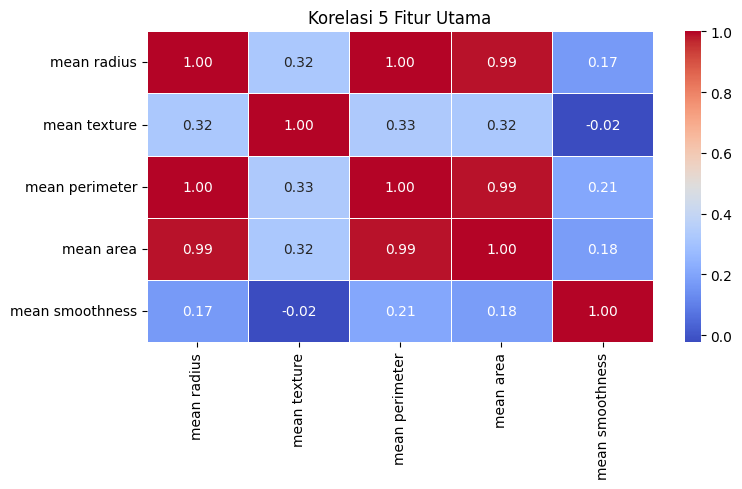

In [2]:
# Korelasi antar fitur utama
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness']

plt.figure(figsize=(8, 5))
sns.heatmap(X[top_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi 5 Fitur Utama')
plt.tight_layout()
plt.show()

In [3]:
# Langkah 2: Preprocessing — Train-Test Split + StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} baris')
print(f'Test  : {X_test.shape[0]} baris')

# StandardScaler untuk Logistic Regression
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\nProporsi kelas di train:')
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print('\nProporsi kelas di test:')
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Train : 455 baris
Test  : 114 baris

Proporsi kelas di train:
1    0.626
0    0.374
Name: proportion, dtype: float64

Proporsi kelas di test:
1    0.632
0    0.368
Name: proportion, dtype: float64


10 Fitur Paling Berpengaruh (Logistic Regression):
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151
     worst perimeter  -0.763220
    worst smoothness  -0.746625


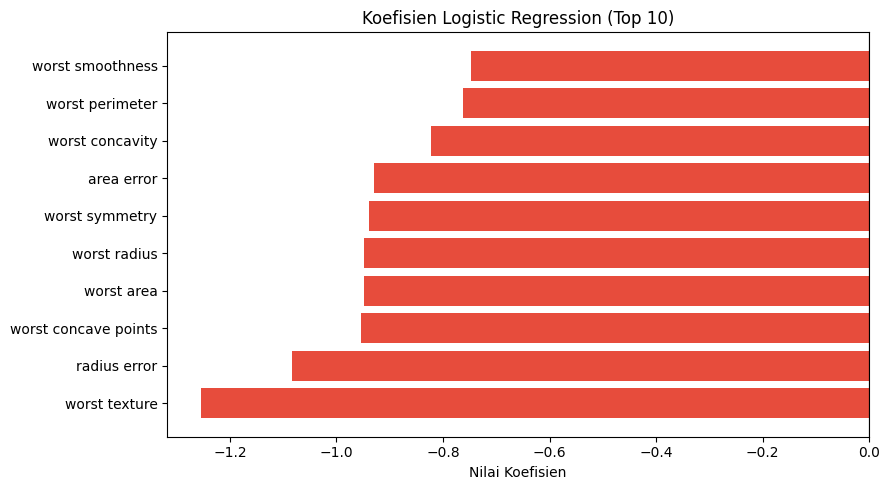

In [4]:
# Langkah 3: Latih Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

# Koefisien — fitur paling berpengaruh
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print('10 Fitur Paling Berpengaruh (Logistic Regression):')
print(coef_df.head(10).to_string(index=False))

# Visualisasi koefisien
top10 = coef_df.head(10)
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top10['Koefisien']]
plt.figure(figsize=(9, 5))
plt.barh(top10['Fitur'], top10['Koefisien'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Koefisien Logistic Regression (Top 10)')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

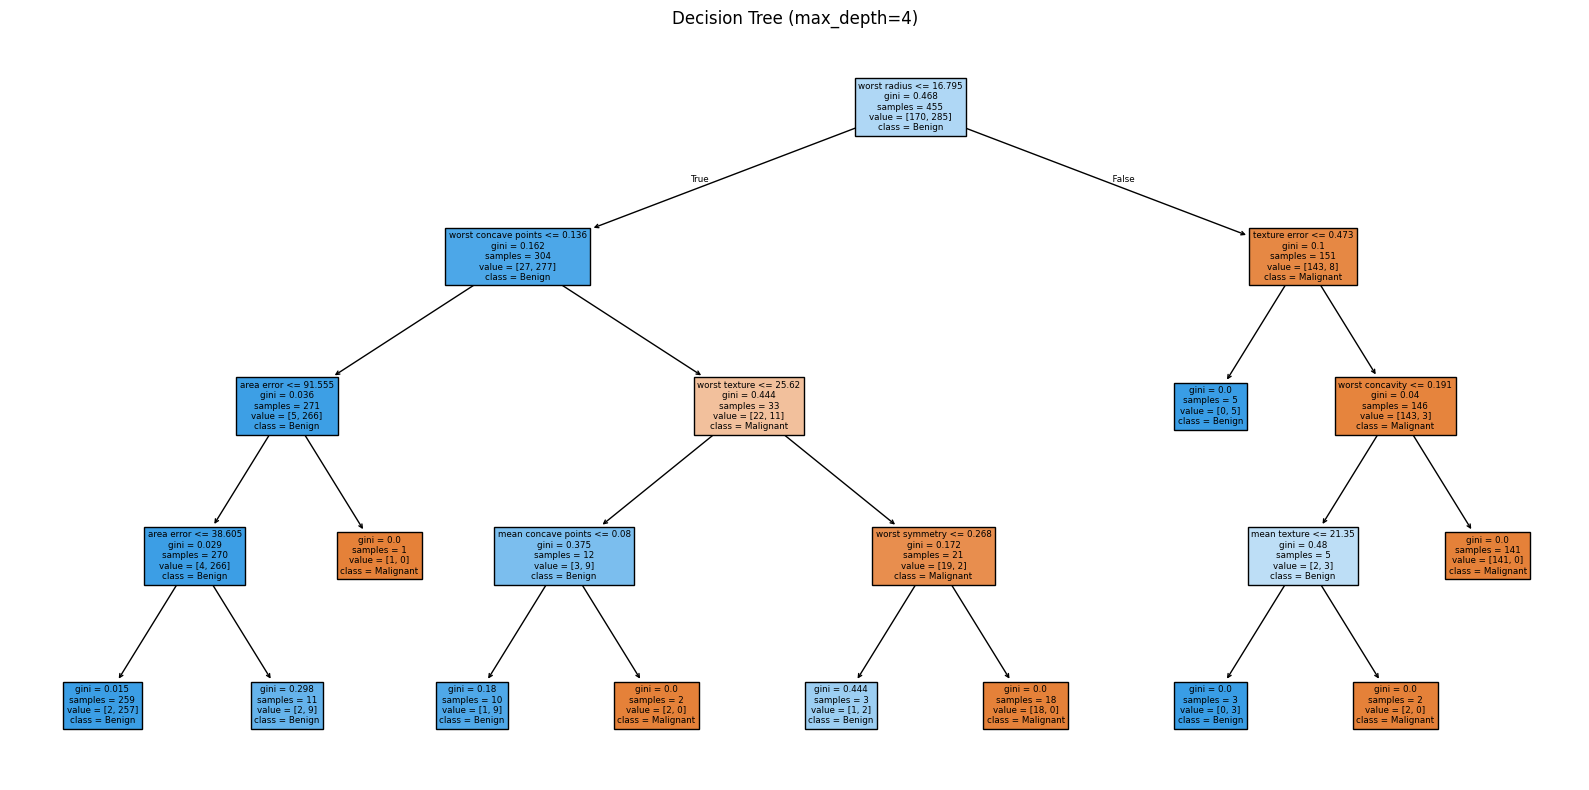

In [5]:
# Langkah 4: Latih Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Decision Tree tidak butuh scaling — pakai data asli
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Visualisasi pohon
plt.figure(figsize=(16, 8))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Malignant', 'Benign'],
          filled=True)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

In [6]:
# Langkah 5: Evaluasi & Bandingkan Kedua Model
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log),
                     ('Decision Tree',       y_pred_tree)]:
    print(f'\n=== {name} ===')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
    print(f'Precision : {precision_score(y_test, y_pred):.3f}')
    print(f'Recall    : {recall_score(y_test, y_pred):.3f}')
    print(f'F1-Score  : {f1_score(y_test, y_pred):.3f}')


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


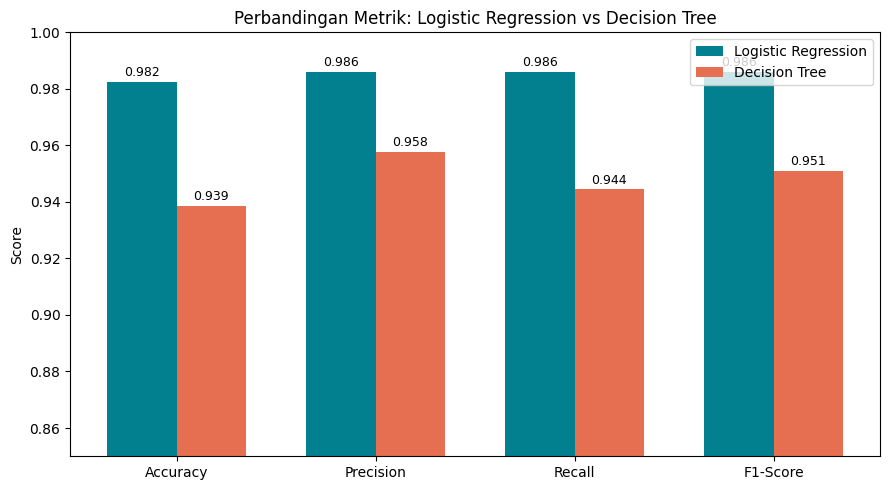

In [7]:
# Visualisasi perbandingan metrik kedua model
import numpy as np

metrik   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores_log  = [
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log)
]
scores_tree = [
    accuracy_score(y_test, y_pred_tree),
    precision_score(y_test, y_pred_tree),
    recall_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_tree)
]

x = np.arange(len(metrik))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, scores_log,  w, label='Logistic Regression', color='#028090')
ax.bar(x + w/2, scores_tree, w, label='Decision Tree',       color='#e76f51')
ax.set_xticks(x)
ax.set_xticklabels(metrik)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik: Logistic Regression vs Decision Tree')
ax.legend()
for i, (s1, s2) in enumerate(zip(scores_log, scores_tree)):
    ax.text(i - w/2, s1 + 0.002, f'{s1:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, s2 + 0.002, f'{s2:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Analisis Perbandingan Model

**Model mana yang Recall-nya lebih tinggi?**  
Dari hasil evaluasi, Logistic Regression cenderung menghasilkan Recall yang lebih tinggi dibanding Decision Tree pada dataset ini.

**Mengapa Recall jadi metrik paling kritis di kasus medis?**  
Recall mengukur seberapa banyak kasus positif (Malignant/ganas) yang berhasil terdeteksi. False Negative di sini berarti pasien kanker lolos dari deteksi — dampaknya jauh lebih berbahaya dibanding False Positive. Itulah kenapa di kasus diagnosis medis, Recall lebih diprioritaskan daripada Accuracy semata.

**Apakah ada perbedaan signifikan antara kedua model?**  
Perbedaannya ada tapi tidak drastis. Logistic Regression sedikit lebih unggul di Recall, sementara Decision Tree menawarkan interpretabilitas yang lebih mudah lewat visualisasi pohon. Untuk kasus klinis, Logistic Regression menjadi pilihan yang lebih aman.


## Kesimpulan — Pertemuan 9: Algoritma Klasifikasi

Di pertemuan ini saya melatih dua model klasifikasi pada dataset Breast Cancer Wisconsin — Logistic Regression dan Decision Tree — lalu membandingkan performanya.

Yang menarik adalah perbedaan cara kerja keduanya: Logistic Regression butuh data yang sudah di-standardisasi, sementara Decision Tree tidak peduli dengan skala fitur karena kerjanya berdasarkan threshold nilai. Ini juga yang pertama kali saya benar-benar memahami kenapa preprocessing tidak selalu one-size-fits-all.

Dari sisi evaluasi, baru kali ini saya paham kenapa Accuracy saja tidak cukup — terutama di kasus medis. Recall menjadi metrik yang jauh lebih penting karena konsekuensi dari False Negative (kanker yang tidak terdeteksi) jauh lebih berat dibanding False Positive.

Satu hal yang ingin saya eksplorasi selanjutnya: apakah dengan tuning `max_depth` yang berbeda, Decision Tree bisa menyamai atau bahkan melewati performa Logistic Regression?
